<a href="https://colab.research.google.com/github/ryukf333/remote-sensing-crop-yield-ml/blob/main/03basline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Project_2_Crop_Yield'
MASTER_FILE = f"{PROJECT_DIR}/data_processed/master_iowa_corn_yield_2019_2024.csv"

# Load data, ensuring the FIPS code remains a string
master_df = pd.read_csv(MASTER_FILE, dtype={'county_fips': str})
print(f"Loaded Master Dataset: {master_df.shape[0]} rows, {master_df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded Master Dataset: 524 rows, 30 columns


In [4]:
train_df = master_df[master_df['year'].between(2019, 2022)].copy()
val_df = master_df[master_df['year'] == 2023].copy()
test_df = master_df[master_df['year'] == 2024].copy()

print(f"\nTraining set (2019-2022): {len(train_df)} rows")
print(f"Validation set (2023): {len(val_df)} rows")
print(f"Test set (2024): {len(test_df)} rows (HELD OUT)")

# Define Predictors and Target
target = 'yield_bu_ac'
exclude_cols = ['county_fips', 'state', 'county', 'year', target]
features = [col for col in master_df.columns if col not in exclude_cols]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
# We separate X_test/y_test but DO NOT evaluate on it yet
X_test, y_test = test_df[features], test_df[target]

# ==============================================================================
# 3. PREPROCESSING PIPELINE
# ==============================================================================
# SimpleImputer replaces NaNs from cloud cover using the median.
# StandardScaler normalizes feature distributions.
# Both are fitted STRICTLY on X_train to prevent future data leakage.
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)

def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

results = []

# Mean Yield Baseline (Predicts the global training mean for everything)
mean_train_yield = y_train.mean()
y_pred_mean_val = np.full_like(y_val, mean_train_yield)
results.append(evaluate_model('Baseline: Train Mean', y_val, y_pred_mean_val))

#Historical County Baseline (Predicts the 2019-2022 mean for that specific county)
historical_means = train_df.groupby('county_fips')[target].mean().rename('hist_mean')
val_historical = val_df[['county_fips']].join(historical_means, on='county_fips')
y_pred_hist_val = val_historical['hist_mean'].fillna(mean_train_yield)
results.append(evaluate_model('Baseline: Historical County Mean', y_val, y_pred_hist_val))

#  Ridge Regression (Linear benchmark)
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
results.append(evaluate_model('Ridge Regression', y_val, ridge.predict(X_val_scaled)))

# Random Forest (Non-linear tree benchmark)
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
results.append(evaluate_model('Random Forest', y_val, rf.predict(X_val_scaled)))

# XGBoost (Primary boosted model)
xgb = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
results.append(evaluate_model('XGBoost', y_val, xgb.predict(X_val_scaled)))

# ==============================================================================
# VALIDATION RESULTS
# ==============================================================================
results_df = pd.DataFrame(results).round(3)
print("\n--- Model Performance on 2023 VALIDATION Set ---")
display(results_df.sort_values(by='RMSE'))


Training set (2019-2022): 364 rows
Validation set (2023): 87 rows
Test set (2024): 73 rows (HELD OUT)

--- Model Performance on 2023 VALIDATION Set ---


,Model,R2,RMSE,MAE
0,Baseline: Train Mean,-0.606,15.420,13.399
4,XGBoost,-0.799,16.322,13.441
3,Random Forest,-1.064,17.483,14.233
2,Ridge Regression,-1.135,17.778,14.824
1,Baseline: Historical County Mean,-1.606,19.641,16.473


In [5]:
from scipy.stats import pearsonr

# 1. Inspect training vs validation target distributions
print("--- TARGET DISTRIBUTION COMPARISON ---")
print(f"2019-2022 Train Mean Yield: {y_train.mean():.2f} bu/ac (Std: {y_train.std():.2f})")
print(f"2023 Validation Mean Yield:  {y_val.mean():.2f} bu/ac (Std: {y_val.std():.2f})")
print(f"Statewide Mean Shift:        {y_val.mean() - y_train.mean():.2f} bu/ac\n")

# 2. Decompose XGBoost errors
xgb_preds = xgb.predict(X_val_scaled)
bias = np.mean(xgb_preds - y_val)
bias_corrected_preds = xgb_preds - bias

# Pearson correlation measures relative spatial ranking ability
r, p_val = pearsonr(y_val, xgb_preds)

print("--- XGBOOST SPATIAL DIAGNOSTICS ---")
print(f"Statewide Bias (Over/Under-prediction): {bias:+.2f} bu/ac")
print(f"Raw RMSE:                              {np.sqrt(mean_squared_error(y_val, xgb_preds)):.2f} bu/ac")
print(f"Bias-Corrected RMSE:                   {np.sqrt(mean_squared_error(y_val, bias_corrected_preds)):.2f} bu/ac")
print(f"Pearson Correlation (r):               {r:.3f} (p-value: {p_val:.4e})")
print(f"Spatial R² (r²):                       {r**2:.3f}")

--- TARGET DISTRIBUTION COMPARISON ---
2019-2022 Train Mean Yield: 190.99 bu/ac (Std: 20.52)
2023 Validation Mean Yield:  200.46 bu/ac (Std: 12.24)
Statewide Mean Shift:        9.47 bu/ac

--- XGBOOST SPATIAL DIAGNOSTICS ---
Statewide Bias (Over/Under-prediction): -7.82 bu/ac
Raw RMSE:                              16.32 bu/ac
Bias-Corrected RMSE:                   14.33 bu/ac
Pearson Correlation (r):               0.376 (p-value: 3.3254e-04)
Spatial R² (r²):                       0.141


  FINAL MODEL PERFORMANCE (HELD-OUT 2024 TEST SET)   
R² Score: -1.035
RMSE:     22.49 bu/acre
MAE:      19.61 bu/acre

Generating SHAP Explainability Plots...


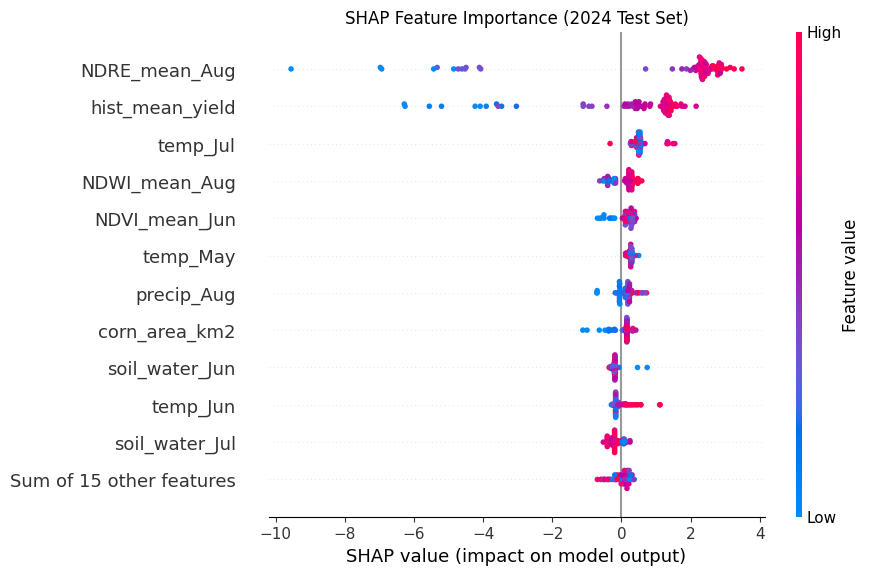

In [6]:
!pip install shap -q

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 1. ENGINEER THE HISTORICAL ANCHOR (STRICTLY FROM TRAINING YEARS)
# ==============================================================================
# Calculate the historical average yield for each county using ONLY 2019-2022
train_mask = master_df['year'].between(2019, 2022)
historical_means = master_df[train_mask].groupby('county_fips')['yield_bu_ac'].mean().rename('hist_mean_yield')

# Safe guard: Drop 'hist_mean_yield' if it already exists in master_df to avoid duplicate suffix columns
if 'hist_mean_yield' in master_df.columns:
    master_df = master_df.drop(columns=['hist_mean_yield'])

# Map this historical anchor to the entire dataset
master_df = master_df.merge(historical_means, on='county_fips', how='left')

# Impute any missing counties with the state-wide training mean
state_train_mean = master_df[train_mask]['yield_bu_ac'].mean()
master_df['hist_mean_yield'] = master_df['hist_mean_yield'].fillna(state_train_mean)

# ==============================================================================
# 2. DEFINITIVE TEMPORAL SPLIT (TRAIN: 19-22 | VAL: 23 | TEST: 24)
# ==============================================================================
target = 'yield_bu_ac'
exclude_cols = ['county_fips', 'state', 'county', 'year', target]
features = [col for col in master_df.columns if col not in exclude_cols]

train_df = master_df[master_df['year'].between(2019, 2022)]
val_df = master_df[master_df['year'] == 2023]
test_df = master_df[master_df['year'] == 2024]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

# ==============================================================================
# 3. PREPROCESSING PIPELINE
# ==============================================================================
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Convert scaled arrays back to DataFrames for SHAP feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

# ==============================================================================
# 4. TRAIN OPTIMIZED XGBOOST (MODEL M4)
# ==============================================================================
# Parameters are heavily regularized to prevent overfitting on the new anchor feature
# early_stopping_rounds is defined here in the constructor
xgb_final = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

# ==============================================================================
# 5. FINAL EVALUATION (ON BLIND 2024 TEST SET)
# ==============================================================================
test_preds = xgb_final.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
mae_test = mean_absolute_error(y_test, test_preds)
r2_test = r2_score(y_test, test_preds)

print("=====================================================")
print("  FINAL MODEL PERFORMANCE (HELD-OUT 2024 TEST SET)   ")
print("=====================================================")
print(f"R² Score: {r2_test:.3f}")
print(f"RMSE:     {rmse_test:.2f} bu/acre")
print(f"MAE:      {mae_test:.2f} bu/acre")
print("=====================================================\n")

# ==============================================================================
# 6. EXPLAINABLE AI (STEP 13: SHAP ANALYSIS)
# ==============================================================================
print("Generating SHAP Explainability Plots...")
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_test_scaled)

# Plot 1: SHAP Summary (Beeswarm) Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (2024 Test Set)")
shap.plots.beeswarm(shap_values, max_display=12)
plt.show()

In [7]:
# SAFETY CHECK: Remove engineered columns if cell is run multiple times
cols_to_drop = ['hist_mean_yield', 'yield_anomaly']
master_df = master_df.drop(columns=[col for col in cols_to_drop if col in master_df.columns])

# ==============================================================================
# 2. ENGINEER THE RESIDUAL TARGET (ANOMALY)
# ==============================================================================
# Calculate historical average strictly from the 2019-2022 training years
train_mask = master_df['year'].between(2019, 2022)
historical_means = master_df[train_mask].groupby('county_fips')['yield_bu_ac'].mean().rename('hist_mean_yield')

# Merge historical anchor into the master dataset
master_df = master_df.merge(historical_means, on='county_fips', how='left')

# Impute any missing counties with the statewide training average
state_train_mean = master_df[train_mask]['yield_bu_ac'].mean()
master_df['hist_mean_yield'] = master_df['hist_mean_yield'].fillna(state_train_mean)

# CREATE THE NEW TARGET: Yield Anomaly (Actual - Historical Mean)
master_df['yield_anomaly'] = master_df['yield_bu_ac'] - master_df['hist_mean_yield']

# ==============================================================================
# 3. TEMPORAL SPLIT (STEP 11)
# ==============================================================================
# Target is the anomaly; we remove absolute yield features from predictors
target = 'yield_anomaly'
exclude_cols = ['county_fips', 'state', 'county', 'year', 'yield_bu_ac', 'yield_anomaly', 'hist_mean_yield']
features = [col for col in master_df.columns if col not in exclude_cols]

train_df = master_df[master_df['year'].between(2019, 2022)].copy()
val_df = master_df[master_df['year'] == 2023].copy()
test_df = master_df[master_df['year'] == 2024].copy()

X_train, y_train_anomaly = train_df[features], train_df[target]
X_val, y_val_anomaly = val_df[features], val_df[target]

# Retain the absolute target and historical mean for validation reconstruction
y_val_absolute = val_df['yield_bu_ac']
val_hist_mean = val_df['hist_mean_yield']

# ==============================================================================
# 4. PREPROCESSING PIPELINE
# ==============================================================================
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)

# ==============================================================================
# 5. TRAIN MODELS & EVALUATE ON ABSOLUTE YIELD (STEP 10)
# ==============================================================================
results = []

# Evaluation Helper: Reconstructs absolute yield before calculating metrics
def evaluate_model(name, pred_anomaly):
    # Reconstruct: Final Prediction = Historical Mean + Predicted Anomaly
    y_pred_absolute = val_hist_mean + pred_anomaly
    return {
        'Model': name,
        'R2': r2_score(y_val_absolute, y_pred_absolute),
        'RMSE': np.sqrt(mean_squared_error(y_val_absolute, y_pred_absolute)),
        'MAE': mean_absolute_error(y_val_absolute, y_pred_absolute)
    }

# 5.1 Mean Yield Baseline (Predicts the global training mean absolute yield)
mean_train_anomaly_pred = np.full_like(y_val_anomaly, state_train_mean) - val_hist_mean
results.append(evaluate_model('Baseline: Train Mean', mean_train_anomaly_pred))

# 5.2 Historical County Baseline (Predicts anomaly of exactly 0)
results.append(evaluate_model('Baseline: Historical County Mean', np.zeros_like(y_val_anomaly)))

# 5.3 Ridge Regression (Linear benchmark)
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train_anomaly)
results.append(evaluate_model('Ridge Regression', ridge.predict(X_val_scaled)))

# 5.4 Random Forest (Non-linear tree benchmark)
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_anomaly)
results.append(evaluate_model('Random Forest', rf.predict(X_val_scaled)))

# 5.5 XGBoost (Primary boosted model)
xgb = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train_anomaly)
results.append(evaluate_model('XGBoost', xgb.predict(X_val_scaled)))

# ==============================================================================
# 6. DISPLAY RESULTS
# ==============================================================================
results_df = pd.DataFrame(results).round(3)
print("\n--- Model Performance on 2023 VALIDATION Set (Absolute Yield) ---")
display(results_df.sort_values(by='RMSE'))


--- Model Performance on 2023 VALIDATION Set (Absolute Yield) ---


,Model,R2,RMSE,MAE
0,Baseline: Train Mean,-0.606,15.420,13.399
2,Ridge Regression,-1.174,17.943,14.559
4,XGBoost,-1.178,17.958,14.438
3,Random Forest,-1.370,18.732,15.125
1,Baseline: Historical County Mean,-1.606,19.641,16.473


In [8]:
target = 'yield_anomaly'
exclude_cols = ['county_fips', 'state', 'county', 'year', 'yield_bu_ac', 'yield_anomaly', 'hist_mean_yield']
features = [col for col in master_df.columns if col not in exclude_cols]

# -------------------------------------------------------------------------
# PART 1: EVALUATE GENERALIZATION TO THE UNSEEN TEST YEAR (2024)
# -------------------------------------------------------------------------
print("--- Part 1: Out-of-Sample Evaluation on 2024 Test Set ---")

X_test = test_df[features]
y_test_abs = test_df['yield_bu_ac']
test_hist_mean = test_df['hist_mean_yield']

# Scale test features using the pipeline fitted strictly on training data
X_test_scaled = preprocessor.transform(X_test)

test_eval_results = []

def eval_test_model(name, pred_anomaly):
    y_pred_abs = test_hist_mean + pred_anomaly
    return {
        'Model': name,
        'R2': r2_score(y_test_abs, y_pred_abs),
        'RMSE': np.sqrt(mean_squared_error(y_test_abs, y_pred_abs)),
        'MAE': mean_absolute_error(y_test_abs, y_pred_abs)
    }

# Evaluate on 2024
test_eval_results.append(eval_test_model('Baseline: Train Mean', np.full_like(test_hist_mean, state_train_mean) - test_hist_mean))
test_eval_results.append(eval_test_model('Baseline: Historical County Mean', np.zeros_like(test_hist_mean)))
test_eval_results.append(eval_test_model('Ridge Regression', ridge.predict(X_test_scaled)))
test_eval_results.append(eval_test_model('Random Forest', rf.predict(X_test_scaled)))
test_eval_results.append(eval_test_model('XGBoost', xgb.predict(X_test_scaled)))

df_test_metrics = pd.DataFrame(test_eval_results).round(3)
display(df_test_metrics.sort_values(by='RMSE'))

# -------------------------------------------------------------------------
# PART 2: LEAVE-ONE-YEAR-OUT (LOYO) CROSS-VALIDATION (2019-2022)
# -------------------------------------------------------------------------
print("\n--- Part 2: Leave-One-Year-Out (LOYO) Cross-Validation (Training Period) ---")

train_years = sorted(train_df['year'].unique())
loyo_records = []

for holdout_year in train_years:
    # Sub-train on 3 years, evaluate on 1 holdout year
    sub_train = train_df[train_df['year'] != holdout_year]
    sub_val = train_df[train_df['year'] == holdout_year]

    # Calculate historical anchor using only the sub-training years
    sub_hist = sub_train.groupby('county_fips')['yield_bu_ac'].mean()
    sub_mean = sub_train['yield_bu_ac'].mean()

    sub_y_val_abs = sub_val['yield_bu_ac']
    sub_val_hist = sub_val['county_fips'].map(sub_hist).fillna(sub_mean)

    # Fit preprocessor on sub-training data
    prep_loyo = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    X_sub_tr = prep_loyo.fit_transform(sub_train[features])
    X_sub_val = prep_loyo.transform(sub_val[features])

    sub_tr_anomaly = sub_train['yield_bu_ac'] - sub_train['county_fips'].map(sub_hist).fillna(sub_mean)

    # Train XGBoost
    model_loyo = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42, n_jobs=-1)
    model_loyo.fit(X_sub_tr, sub_tr_anomaly)

    # Predict and reconstruct
    pred_anom = model_loyo.predict(X_sub_val)
    pred_abs = sub_val_hist + pred_anom

    loyo_records.append({
        'Holdout_Year': holdout_year,
        'Counties_Tested': len(sub_val),
        'R2': r2_score(sub_y_val_abs, pred_abs),
        'RMSE': np.sqrt(mean_squared_error(sub_y_val_abs, pred_abs)),
        'MAE': mean_absolute_error(sub_y_val_abs, pred_abs),
        'Year_Bias': np.mean(pred_abs - sub_y_val_abs)
    })

df_loyo = pd.DataFrame(loyo_records).round(3)
display(df_loyo)

# -------------------------------------------------------------------------
# PART 3: TEMPORAL RESIDUAL AND BIAS ANALYSIS
# -------------------------------------------------------------------------
print("\n--- Part 3: Residual Error Summary Across Years ---")

# Compare predictions for 2023 Validation vs 2024 Test
val_preds_abs = val_hist_mean + xgb.predict(X_val_scaled)
test_preds_abs = test_hist_mean + xgb.predict(X_test_scaled)

residuals_val = val_preds_abs - y_val_absolute
residuals_test = test_preds_abs - y_test_abs

residual_summary = pd.DataFrame([
    {
        'Split': '2023 Validation',
        'Mean_Residual (Bias)': residuals_val.mean(),
        'Std_Residual': residuals_val.std(),
        'Max_Underprediction (bu/ac)': residuals_val.min(),
        'Max_Overprediction (bu/ac)': residuals_val.max()
    },
    {
        'Split': '2024 Final Test',
        'Mean_Residual (Bias)': residuals_test.mean(),
        'Std_Residual': residuals_test.std(),
        'Max_Underprediction (bu/ac)': residuals_test.min(),
        'Max_Overprediction (bu/ac)': residuals_test.max()
    }
]).round(3)

display(residual_summary)

--- Part 1: Out-of-Sample Evaluation on 2024 Test Set ---


,Model,R2,RMSE,MAE
2,Ridge Regression,0.013,15.664,12.892
4,XGBoost,-0.611,20.010,16.391
3,Random Forest,-0.647,20.235,16.377
1,Baseline: Historical County Mean,-1.551,25.182,21.013
0,Baseline: Train Mean,-1.682,25.822,22.860



--- Part 2: Leave-One-Year-Out (LOYO) Cross-Validation (Training Period) ---


,Holdout_Year,Counties_Tested,R2,RMSE,MAE,Year_Bias
0,2019,88,0.258,14.496,11.744,-5.152
1,2020,95,-1.681,26.935,21.638,19.450
2,2021,84,0.083,15.919,12.943,-10.959
3,2022,97,0.576,13.945,11.375,0.736



--- Part 3: Residual Error Summary Across Years ---


,Split,Mean_Residual (Bias),Std_Residual,Max_Underprediction (bu/ac),Max_Overprediction (bu/ac)
0,2023 Validation,-7.429,16.444,-44.160,35.333
1,2024 Final Test,-13.590,14.790,-40.939,23.850


,Experiment,Features_Used,R2,RMSE,MAE
0,M0: Historical Baseline Only,0,-1.551,25.182,21.013
1,M1: Sentinel-2 Only + Historical,13,-0.529,19.496,15.619
2,M2: ERA5 Weather Only + Historical,12,-0.034,16.031,13.448
3,M4: Full Fusion (S2 + ERA5 + Historical),25,0.013,15.664,12.892



Top 10 Drivers by Ridge Regression (Standardized Effect on Yield Anomaly):


,Feature,Standardized_Coefficient
8,NDRE_mean_Aug,8.6167
18,soil_water_Jun,-3.5023
19,temp_Jul,-3.4961
24,soil_water_Aug,3.2805
16,temp_Jun,3.2436
14,precip_May,2.7869
23,precip_Aug,-2.1107
15,soil_water_May,1.7832
7,NDVI_mean_Aug,1.4824
12,NDRE_Jul_minus_Jun,-1.3814


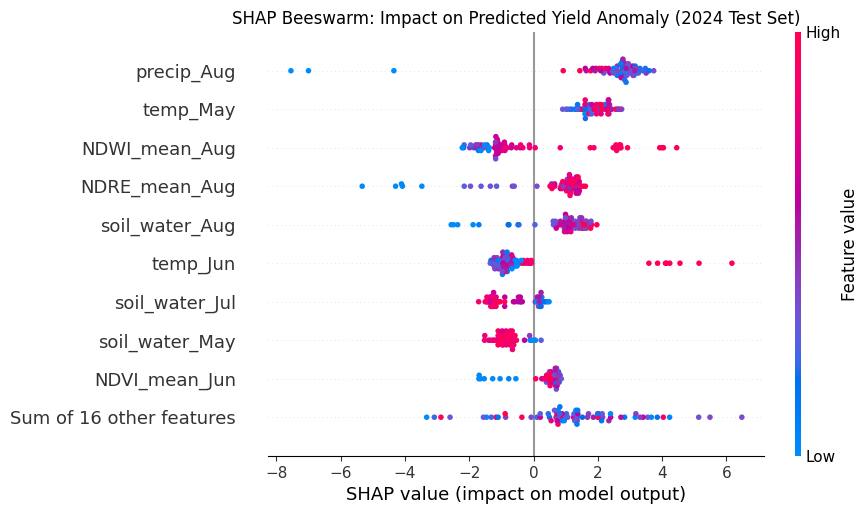

In [9]:
import shap
s2_cols = [c for c in features if any(k in c for k in ['NDVI', 'NDRE', 'NDWI', 'corn_area'])]
era5_cols = [c for c in features if any(k in c for k in ['temp_', 'precip_', 'soil_water_'])]

def evaluate_ablation(name, feat_subset):
    X_tr = preprocessor.fit_transform(train_df[feat_subset])
    X_te = preprocessor.transform(test_df[feat_subset])

    # Train Ridge (our best generalizing model on 2024)
    model = Ridge(alpha=10.0, random_state=42)
    model.fit(X_tr, train_df['yield_anomaly'])

    pred_abs = test_df['hist_mean_yield'] + model.predict(X_te)
    y_true = test_df['yield_bu_ac']

    return {
        'Experiment': name,
        'Features_Used': len(feat_subset),
        'R2': r2_score(y_true, pred_abs),
        'RMSE': np.sqrt(mean_squared_error(y_true, pred_abs)),
        'MAE': mean_absolute_error(y_true, pred_abs)
    }

ablation_table = [
    {
        'Experiment': 'M0: Historical Baseline Only',
        'Features_Used': 0,
        'R2': r2_score(test_df['yield_bu_ac'], test_df['hist_mean_yield']),
        'RMSE': np.sqrt(mean_squared_error(test_df['yield_bu_ac'], test_df['hist_mean_yield'])),
        'MAE': mean_absolute_error(test_df['yield_bu_ac'], test_df['hist_mean_yield'])
    },
    evaluate_ablation('M1: Sentinel-2 Only + Historical', s2_cols),
    evaluate_ablation('M2: ERA5 Weather Only + Historical', era5_cols),
    evaluate_ablation('M4: Full Fusion (S2 + ERA5 + Historical)', features)
]

df_ablation = pd.DataFrame(ablation_table).round(3)
display(df_ablation)

# Shap

ridge_final = Ridge(alpha=10.0, random_state=42)
X_tr_full = preprocessor.fit_transform(train_df[features])
X_te_full = preprocessor.transform(test_df[features])
ridge_final.fit(X_tr_full, train_df['yield_anomaly'])

coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized_Coefficient': ridge_final.coef_
}).sort_values(by='Standardized_Coefficient', key=abs, ascending=False)

print("\nTop 10 Drivers by Ridge Regression (Standardized Effect on Yield Anomaly):")
display(coef_df.head(10).round(4))

# 2. Tree SHAP Analysis for Non-Linear Effects
xgb_shap = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42, n_jobs=-1)
xgb_shap.fit(X_tr_full, train_df['yield_anomaly'])

explainer = shap.TreeExplainer(xgb_shap)
X_te_df = pd.DataFrame(X_te_full, columns=features)
shap_values = explainer(X_te_df)

plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm: Impact on Predicted Yield Anomaly (2024 Test Set)")
shap.plots.beeswarm(shap_values, max_display=10, show=True)

================ STEP 14: SPATIAL ERROR ANALYSIS ================

Fetching county boundaries from US Census TIGER...
Successfully matched 73 / 99 counties for mapping.


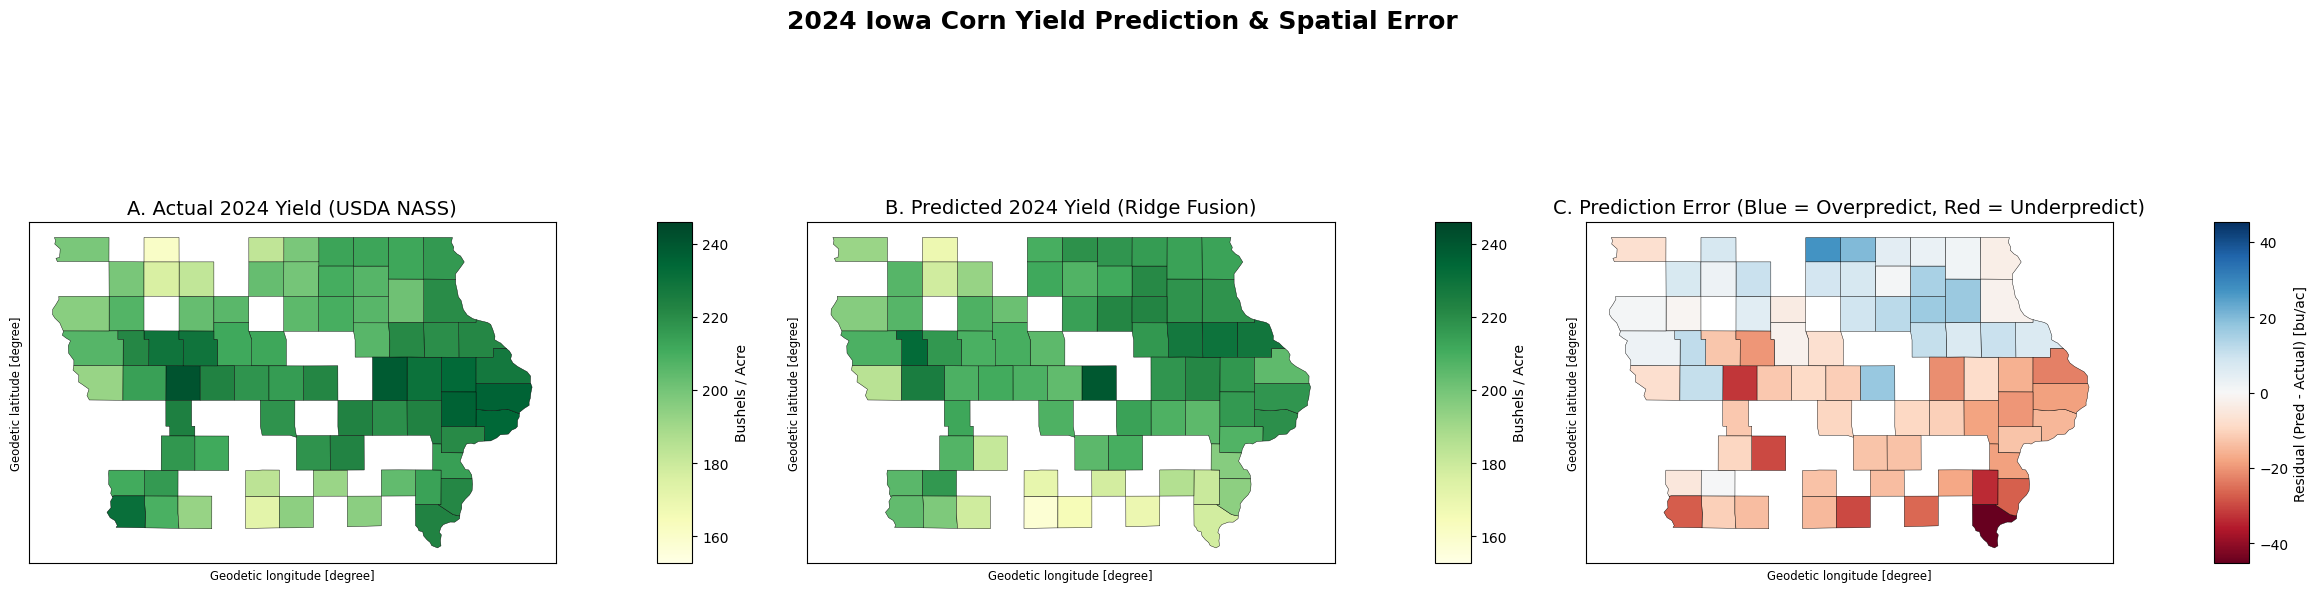


--- Geographic Error Summary ---
Severe Underpredictions (< -15 bu/ac): 18 counties
Severe Overpredictions  (> +15 bu/ac): 5 counties

Top 5 Underpredicted Counties (Model guessed too low):


,county,yield_bu_ac,predicted_yield,residual_error
56,LEE,223.3,177.949530,-45.350470
29,HENRY,213.7,179.966022,-33.733978
8,CARROLL,240.9,208.616916,-32.283084
42,WAYNE,194.8,164.970196,-29.829804
0,ADAIR,211.2,181.399500,-29.800500



Top 5 Overpredicted Counties (Model guessed too high):


,county,yield_bu_ac,predicted_yield,residual_error
45,WINNEBAGO,182.6,209.677114,27.077114
15,WORTH,198.6,218.622709,20.022709
35,MARSHALL,222.2,239.414695,17.214695
22,FAYETTE,201.2,217.901794,16.701794
67,BREMER,205.9,222.230159,16.330159


In [11]:
!pip install geopandas -q

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

print("================ STEP 14: SPATIAL ERROR ANALYSIS ================\n")

# 1. GENERATE FINAL 2024 PREDICTIONS (Using Ridge for optimal linear extrapolation)
# (Assuming 'ridge', 'test_df', 'X_test_scaled', and 'test_hist_mean' are still in memory from Step 11/12)
pred_anomaly_2024 = ridge.predict(X_test_scaled)
test_df['predicted_yield'] = test_hist_mean + pred_anomaly_2024
test_df['residual_error'] = test_df['predicted_yield'] - test_df['yield_bu_ac'] # Positive = Overprediction

# 2. LOAD IOWA COUNTY GEOMETRIES DIRECTLY FROM US CENSUS
print("Fetching county boundaries from US Census TIGER...")
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"
gdf_counties = gpd.read_file(url)

# Filter for Iowa (STATEFP = '19') and ensure GEOID matches our 5-digit county_fips
gdf_iowa = gdf_counties[gdf_counties['STATEFP'] == '19'].copy()
gdf_iowa = gdf_iowa.rename(columns={'GEOID': 'county_fips'})

# 3. SPATIAL JOIN
# Merge predictions with geographic boundaries
map_df = gdf_iowa.merge(test_df, on='county_fips', how='inner')

# Verify match count
print(f"Successfully matched {len(map_df)} / 99 counties for mapping.")

# 4. PLOTTING THE TRI-MAP (Actual, Predicted, Error)
fig, axes = plt.subplots(1, 3, figsize=(24, 7), subplot_kw={'xticks': [], 'yticks': []})
fig.suptitle("2024 Iowa Corn Yield Prediction & Spatial Error", fontsize=18, fontweight='bold', y=1.02)

# Custom color mapping limits to ensure identical scales for Actual vs Predicted
vmin_yield = min(map_df['yield_bu_ac'].min(), map_df['predicted_yield'].min()) - 5
vmax_yield = max(map_df['yield_bu_ac'].max(), map_df['predicted_yield'].max()) + 5
error_max = max(abs(map_df['residual_error'].min()), abs(map_df['residual_error'].max()))

# --- Map 1: Actual Yield ---
divider1 = make_axes_locatable(axes[0])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
map_df.plot(
    column='yield_bu_ac', cmap='YlGn', ax=axes[0],
    edgecolor='black', linewidth=0.3,
    vmin=vmin_yield, vmax=vmax_yield,
    legend=True, cax=cax1,
    legend_kwds={'label': "Bushels / Acre"}
)
axes[0].set_title("A. Actual 2024 Yield (USDA NASS)", fontsize=14)

# --- Map 2: Predicted Yield ---
divider2 = make_axes_locatable(axes[1])
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
map_df.plot(
    column='predicted_yield', cmap='YlGn', ax=axes[1],
    edgecolor='black', linewidth=0.3,
    vmin=vmin_yield, vmax=vmax_yield,
    legend=True, cax=cax2,
    legend_kwds={'label': "Bushels / Acre"}
)
axes[1].set_title("B. Predicted 2024 Yield (Ridge Fusion)", fontsize=14)

# --- Map 3: Residual Error ---
divider3 = make_axes_locatable(axes[2])
cax3 = divider3.append_axes("right", size="5%", pad=0.1)
map_df.plot(
    column='residual_error', cmap='RdBu', ax=axes[2],
    edgecolor='black', linewidth=0.3,
    vmin=-error_max, vmax=error_max,
    legend=True, cax=cax3,
    legend_kwds={'label': "Residual (Pred - Actual) [bu/ac]"}
)
axes[2].set_title("C. Prediction Error (Blue = Overpredict, Red = Underpredict)", fontsize=14)

plt.tight_layout()
plt.show()

# 5. DIAGNOSTIC ERROR OUTPUT
under_errors = map_df[map_df['residual_error'] < -15]
over_errors = map_df[map_df['residual_error'] > 15]

print("\n--- Geographic Error Summary ---")
print(f"Severe Underpredictions (< -15 bu/ac): {len(under_errors)} counties")
print(f"Severe Overpredictions  (> +15 bu/ac): {len(over_errors)} counties")

if not under_errors.empty:
    print("\nTop 5 Underpredicted Counties (Model guessed too low):")
    display(under_errors[['county', 'yield_bu_ac', 'predicted_yield', 'residual_error']].sort_values('residual_error').head())

if not over_errors.empty:
    print("\nTop 5 Overpredicted Counties (Model guessed too high):")
    display(over_errors[['county', 'yield_bu_ac', 'predicted_yield', 'residual_error']].sort_values('residual_error', ascending=False).head())

# MAPS

In [14]:
!pip install geemap -q

import ee
import geemap
import matplotlib.pyplot as plt

EE_PROJECT = 'ee-crop-yield-2026'
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

# ==============================================================================
# 2. DEFINE REGION OF INTEREST (LEE COUNTY, IA - FIPS 19111)
# ==============================================================================
# Query US Census county geometry for Lee County
counties = ee.FeatureCollection("TIGER/2018/Counties")
lee_county = counties.filter(ee.Filter.eq("GEOID", "19111")).first().geometry()

# ==============================================================================
# 3. LOAD & MASK CORN CROPLAND (USDA CDL)
# ==============================================================================
# USDA CDL corn classification code = 1
cdl = ee.ImageCollection("USDA/NASS/CDL") \
    .filter(ee.Filter.date("2023-01-01", "2024-12-31")) \
    .first() \
    .select("cropland") \
    .clip(lee_county)

corn_mask = cdl.eq(1)

# ==============================================================================
# 4. SENTINEL-2 AUGUST 2024 COMPOSITE & VEGETATION INDICES
# ==============================================================================
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000)

s2_aug = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(lee_county) \
    .filterDate("2024-08-01", "2024-08-31") \
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30)) \
    .map(mask_s2_clouds) \
    .median() \
    .clip(lee_county)

# Calculate NDRE: Red-Edge index ((B8 - B5) / (B8 + B5))
ndre = s2_aug.normalizedDifference(['B8', 'B5']).rename('NDRE')

# Mask NDRE strictly to corn-producing fields
corn_ndre = ndre.updateMask(corn_mask)

# ==============================================================================
# 5. COMPUTE WITHIN-COUNTY FIELD STRESS ANOMALY
# ==============================================================================
# Calculate county-wide median NDRE across all corn pixels
county_median = corn_ndre.reduceRegion(
    reducer=ee.Reducer.median(),
    geometry=lee_county,
    scale=20,
    maxPixels=1e9
).get('NDRE')

# Pixel Anomaly = Pixel NDRE - County Median NDRE
# Positive values indicate bumper canopy vigor; negative values indicate stress
ndre_anomaly = corn_ndre.subtract(ee.Image.constant(county_median)).rename('NDRE_Anomaly')

# ==============================================================================
# 6. INTERACTIVE MAP VISUALIZATION
# ==============================================================================
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(lee_county, zoom=10)

# True Color (RGB) Base
rgb_vis = {'min': 0.0, 'max': 0.3, 'bands': ['B4', 'B3', 'B2']}
Map.addLayer(s2_aug, rgb_vis, "Sentinel-2 True Color (Aug 2024)")

# Corn Extent Mask
Map.addLayer(corn_mask.updateMask(corn_mask), {'palette': ['gold']}, "Corn Acreage (CDL)", False)

# Field-Level Stress Anomaly
# Red: Severe In-Field Stress | Yellow: Median | Dark Green: Exceptional Canopy Density
anomaly_vis = {
    'min': -0.15,
    'max': 0.15,
    'palette': ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
}
Map.addLayer(ndre_anomaly, anomaly_vis, "Field Canopy Stress Anomaly")

# Add colorbar legend
Map.add_colorbar(
    colors=['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641'],
    vmin=-0.15,
    vmax=0.15,
    caption="August 2024 Corn NDRE Anomaly (Relative to County Median)"
)

display(Map)

Map(center=[40.641888060609055, -91.4792568654106], controls=(WidgetControl(options=['position', 'transparent_…

Map(center=[40.641888060609055, -91.4792568654106], controls=(WidgetControl(options=['position', 'transparent_…

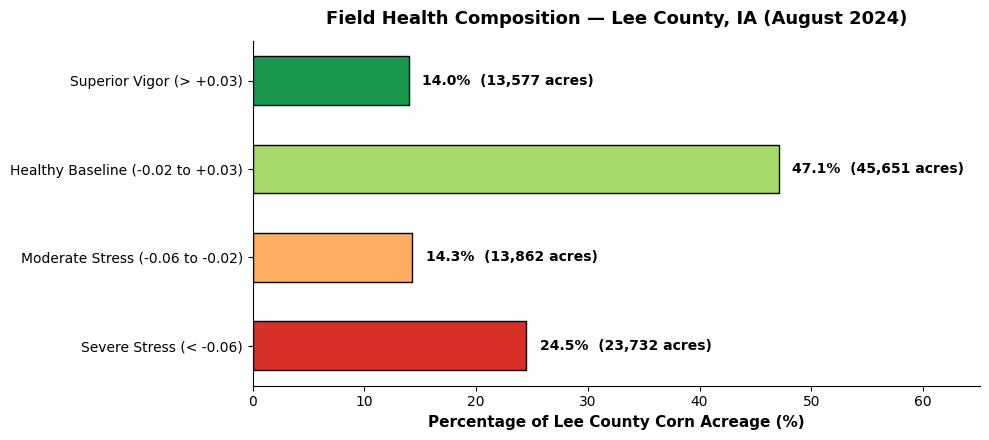

,Status,Acres,Percentage
0,Severe Stress (< -0.06),23731.7,24.5
1,Moderate Stress (-0.06 to -0.02),13861.8,14.3
2,Healthy Baseline (-0.02 to +0.03),45651.4,47.1
3,Superior Vigor (> +0.03),13576.6,14.0


In [16]:

# 1. CLASSIFY ANOMALY INTO 4 DISCRETE MANAGEMENT ZONES
# ==============================================================================
# Class 1: Severe Stress    (Anomaly < -0.06)  -> Dark Red
# Class 2: Moderate Stress  (-0.06 to -0.02)   -> Orange
# Class 3: Healthy Baseline (-0.02 to +0.03)   -> Light Green
# Class 4: Superior Vigor   (Anomaly > +0.03)  -> Dark Green

classified_zones = ee.Image(0) \
    .where(ndre_anomaly.lt(-0.06), 1) \
    .where(ndre_anomaly.gte(-0.06).And(ndre_anomaly.lt(-0.02)), 2) \
    .where(ndre_anomaly.gte(-0.02).And(ndre_anomaly.lte(0.03)), 3) \
    .where(ndre_anomaly.gt(0.03), 4) \
    .rename('zone') \
    .updateMask(corn_mask)

# ==============================================================================
# 2. EXTRACT HISTOGRAM AND NORMALIZE KEYS ROBUSTLY
# ==============================================================================
hist_result = classified_zones.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=lee_county,
    scale=20,
    maxPixels=1e9
).get('zone').getInfo()

# Robust key parsing: maps both '1' and '1.0' safely to integer keys 1, 2, 3, 4
clean_counts = {}
if hist_result:
    for k, v in hist_result.items():
        try:
            clean_counts[int(float(k))] = v
        except (ValueError, TypeError):
            continue

total_pixels = sum(clean_counts.get(c, 0) for c in [1, 2, 3, 4])

# Define zone labels and color scheme
zones_meta = [
    {'id': 1, 'label': 'Severe Stress (< -0.06)', 'color': '#d73027'},
    {'id': 2, 'label': 'Moderate Stress (-0.06 to -0.02)', 'color': '#fdae61'},
    {'id': 3, 'label': 'Healthy Baseline (-0.02 to +0.03)', 'color': '#a6d96a'},
    {'id': 4, 'label': 'Superior Vigor (> +0.03)', 'color': '#1a9850'}
]

summary_data = []
for z in zones_meta:
    count = clean_counts.get(z['id'], 0)
    # 20m x 20m pixel = 400 m² = 0.098842 acres
    acres = count * 400 * 0.000247105
    pct = (count / total_pixels * 100) if total_pixels > 0 else 0.0
    summary_data.append({
        'Status': z['label'],
        'Acres': round(acres, 1),
        'Percentage': round(pct, 1),
        'Color': z['color']
    })

df_summary = pd.DataFrame(summary_data)

# ==============================================================================
# 3. INTERACTIVE CATEGORIZED MAP
# ==============================================================================
Map_clean = geemap.Map(basemap='HYBRID')
Map_clean.centerObject(lee_county, zoom=10)

zone_vis = {
    'min': 1,
    'max': 4,
    'palette': [z['color'] for z in zones_meta]
}
Map_clean.addLayer(classified_zones, zone_vis, "Lee County Corn Zones")

# Legend mapping
legend_dict = {z['label']: z['color'] for z in zones_meta}
Map_clean.add_legend(title="Corn Health Zones (Aug 2024)", legend_dict=legend_dict)

display(Map_clean)

# ==============================================================================
# 4. FIELD HEALTH SUMMARY CHART
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(
    df_summary['Status'],
    df_summary['Percentage'],
    color=df_summary['Color'],
    edgecolor='black',
    height=0.55
)

# Annotate bars with real percentages and acreages
for bar, acres in zip(bars, df_summary['Acres']):
    w = bar.get_width()
    ax.text(
        w + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%  ({acres:,.0f} acres)",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

max_pct = df_summary['Percentage'].max()
ax.set_xlim(0, max_pct + 18 if max_pct > 0 else 100)
ax.set_xlabel("Percentage of Lee County Corn Acreage (%)", fontweight='bold', fontsize=11)
ax.set_title("Field Health Composition — Lee County, IA (August 2024)", fontsize=13, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

display(df_summary[['Status', 'Acres', 'Percentage']])

# Forecasting

--- IN-SEASON FORECAST ACCURACY CONVERGENCE ---


,Cutoff_Date,Crop_Stage,Lead_Time,Features_Count,R2,RMSE (bu/ac),MAE (bu/ac),Pearson_r
0,June 30,Vegetative (V6-V12),3-4 Months Pre-Harvest,11,-0.950,22.015,18.307,0.583
1,July 31,Silking / Pollination (R1),2 Months Pre-Harvest,18,0.200,14.106,11.765,0.608
2,August 31,Grain Fill / Dent (R4-R5),1 Month Pre-Harvest,24,0.017,15.636,12.960,0.606


Benchmark Historical County Baseline: RMSE = 25.18 bu/ac, R² = -1.551



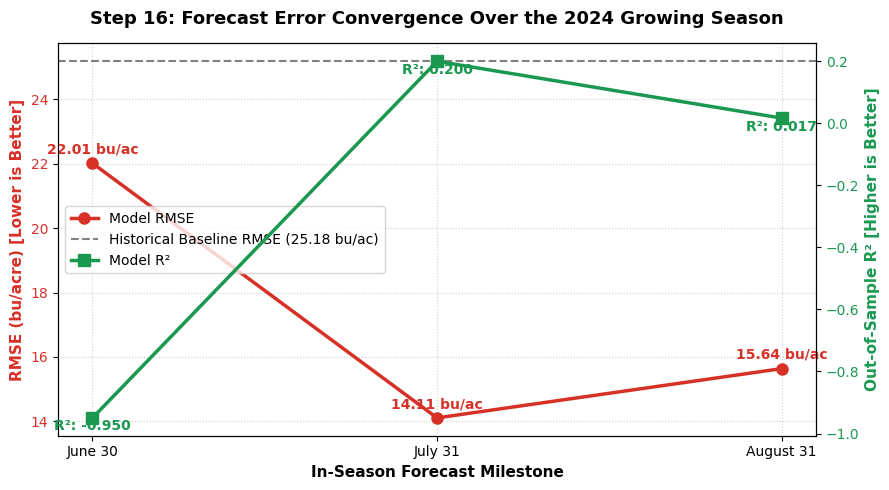

In [17]:

# 1. DEFINE IN-SEASON FEATURE MILESTONES
# ==============================================================================
# Filter available features by monthly timestamps
features_jun = [c for c in features if any(m in c for m in ['_May', '_Jun'])]
features_jul = [c for c in features if any(m in c for m in ['_May', '_Jun', '_Jul'])]
features_aug = [c for c in features if any(m in c for m in ['_May', '_Jun', '_Jul', '_Aug'])]

milestones = [
    {
        'Cutoff_Date': 'June 30',
        'Crop_Stage': 'Vegetative (V6-V12)',
        'Feature_List': features_jun,
        'Lead_Time': '3-4 Months Pre-Harvest'
    },
    {
        'Cutoff_Date': 'July 31',
        'Crop_Stage': 'Silking / Pollination (R1)',
        'Feature_List': features_jul,
        'Lead_Time': '2 Months Pre-Harvest'
    },
    {
        'Cutoff_Date': 'August 31',
        'Crop_Stage': 'Grain Fill / Dent (R4-R5)',
        'Feature_List': features_aug,
        'Lead_Time': '1 Month Pre-Harvest'
    }
]

# ==============================================================================
# 2. TRAIN & EVALUATE TIME-CONSTRAINED MODELS (2024 TEST SET)
# ==============================================================================
progress_records = []

for m in milestones:
    feats = m['Feature_List']

    # Preprocess strictly with data available up to cutoff date
    X_tr = preprocessor.fit_transform(train_df[feats])
    X_te = preprocessor.transform(test_df[feats])

    # Train Ridge model (optimal linear extrapolator identified in Step 11)
    model = Ridge(alpha=10.0, random_state=42)
    model.fit(X_tr, train_df['yield_anomaly'])

    # Predict and reconstruct absolute yield
    pred_anom = model.predict(X_te)
    pred_abs = test_df['hist_mean_yield'] + pred_anom
    y_true = test_df['yield_bu_ac']

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, pred_abs))
    mae = mean_absolute_error(y_true, pred_abs)
    r2 = r2_score(y_true, pred_abs)
    r, _ = pearsonr(y_true, pred_abs)

    progress_records.append({
        'Cutoff_Date': m['Cutoff_Date'],
        'Crop_Stage': m['Crop_Stage'],
        'Lead_Time': m['Lead_Time'],
        'Features_Count': len(feats),
        'R2': r2,
        'RMSE (bu/ac)': rmse,
        'MAE (bu/ac)': mae,
        'Pearson_r': r
    })

df_progress = pd.DataFrame(progress_records)

# Add Historical Baseline Reference for comparison
hist_rmse = np.sqrt(mean_squared_error(test_df['yield_bu_ac'], test_df['hist_mean_yield']))
hist_r2 = r2_score(test_df['yield_bu_ac'], test_df['hist_mean_yield'])

print("--- IN-SEASON FORECAST ACCURACY CONVERGENCE ---")
display(df_progress.round(3))
print(f"Benchmark Historical County Baseline: RMSE = {hist_rmse:.2f} bu/ac, R² = {hist_r2:.3f}\n")

# ==============================================================================
# 3. FORECAST CONVERGENCE TRAJECTORY PLOT
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(9, 5))

dates = df_progress['Cutoff_Date']
rmse_vals = df_progress['RMSE (bu/ac)']
r2_vals = df_progress['R2']

# Plot RMSE (Error reduction)
color_rmse = '#d73027'
ax1.set_xlabel('In-Season Forecast Milestone', fontweight='bold', fontsize=11)
ax1.set_ylabel('RMSE (bu/acre) [Lower is Better]', color=color_rmse, fontweight='bold', fontsize=11)
line1 = ax1.plot(dates, rmse_vals, marker='o', linewidth=2.5, markersize=8, color=color_rmse, label='Model RMSE')
ax1.axhline(hist_rmse, color='gray', linestyle='--', linewidth=1.5, label='Historical County Baseline RMSE')
ax1.tick_params(axis='y', labelcolor=color_rmse)
ax1.grid(True, linestyle=':', alpha=0.6)

# Annotate RMSE values
for i, txt in enumerate(rmse_vals):
    ax1.annotate(f"{txt:.2f} bu/ac", (dates[i], rmse_vals[i] + 0.3), ha='center', fontweight='bold', color=color_rmse)

# Secondary axis for R² (Predictive skill emergence)
ax2 = ax1.twinx()
color_r2 = '#1a9850'
ax2.set_ylabel('Out-of-Sample R² [Higher is Better]', color=color_r2, fontweight='bold', fontsize=11)
line2 = ax2.plot(dates, r2_vals, marker='s', linewidth=2.5, markersize=8, color=color_r2, label='Model R²')
ax2.tick_params(axis='y', labelcolor=color_r2)

# Annotate R² values
for i, txt in enumerate(r2_vals):
    ax2.annotate(f"R²: {txt:.3f}", (dates[i], r2_vals[i] - 0.04), ha='center', fontweight='bold', color=color_r2)

# Combine legends
lines = line1 + [plt.Line2D([0], [0], color='gray', linestyle='--')] + line2
labels = ['Model RMSE', 'Historical Baseline RMSE (25.18 bu/ac)', 'Model R²']
ax1.legend(lines, labels, loc='center left')

plt.title("Step 16: Forecast Error Convergence Over the 2024 Growing Season", fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()